<a href="https://colab.research.google.com/github/Shizukem/cu-i-k-/blob/main/b%C3%A0i_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files

uploaded = files.upload()

Saving vietnam_sectors_2024.csv to vietnam_sectors_2024.csv


In [2]:
import pandas as pd

print("\n" + "="*100)
print("3.4.1: CHUẨN HÓA DỮ LIỆU MIN-MAX [0,1]")
print("="*100)

# Dữ liệu 10 ngành Việt Nam 2024
print("\n[A] DỮ LIỆU ĐẦU VÀO:\n")

data = {
    'Ngành': [
        '1. Nông-Lâm-Thủy sản',
        '2. CN chế biến chế tạo',
        '3. Xây dựng',
        '4. Khai khoáng',
        '5. Bán buôn-bán lẻ',
        '6. Tài chính-Ngân hàng',
        '7. Logistics-Vận tải',
        '8. CNIT-Truyền thông',
        '9. Giáo dục-Đào tạo',
        '10. Y tế'
    ],
    'Growth': [3.27, 9.64, 7.45, -1.20, 7.10, 7.36, 9.93, 7.85, 6.42, 6.85],
    'Productivity': [103.4, 241.2, 168.8, 1290.5, 145.3, 1072.4, 321.4, 713.8, 205.7, 437.1],
    'Spillover': [0.35, 0.78, 0.42, 0.30, 0.55, 0.85, 0.72, 0.92, 0.65, 0.60],
    'Export': [40.5, 290.9, 2.5, 8.2, 5.5, 1.2, 3.1, 178.0, 0.0, 0.0],
    'Employment': [13.20, 11.50, 4.80, 0.30, 7.80, 0.55, 1.95, 0.62, 2.15, 0.75],
    'AI_Readiness': [15, 55, 20, 30, 48, 72, 42, 88, 38, 45],
    'Risk': [18, 42, 25, 55, 38, 52, 35, 28, 22, 18]
}

df = pd.DataFrame(data)
print(df.to_string(index=False))

# Chuẩn hóa min-max
print("\n[B] CÔNG THỨC CHUẨN HÓA MIN-MAX:\n")
print("  x_normalized = (x - x_min) / (x_max - x_min)")
print("\n  Risk (chỉ số 'xấu'): x_normalized = (x_max - x) / (x_max - x_min)")
print("                       → Cao = thấp, Thấp = cao\n")

df_norm = df.copy()

# Chuẩn hóa từng cột
def normalize_benefit(col):
    """Chuẩn hóa chỉ số 'tốt' (cao = tốt)"""
    return (col - col.min()) / (col.max() - col.min())

def normalize_cost(col):
    """Chuẩn hóa chỉ số 'xấu' (thấp = tốt)"""
    return (col.max() - col) / (col.max() - col.min())

df_norm['Growth_n'] = normalize_benefit(df['Growth'])
df_norm['Productivity_n'] = normalize_benefit(df['Productivity'])
df_norm['Spillover_n'] = normalize_benefit(df['Spillover'])
df_norm['Export_n'] = normalize_benefit(df['Export'])
df_norm['Employment_n'] = normalize_benefit(df['Employment'])
df_norm['AI_Readiness_n'] = normalize_benefit(df['AI_Readiness'])
df_norm['Risk_n'] = normalize_cost(df['Risk'])  # ← ĐẢO DẤU

print("[C] MA TRẬN CHUẨN HÓA (Normalized Values):\n")

norm_cols = ['Ngành', 'Growth_n', 'Productivity_n', 'Spillover_n', 'Export_n',
             'Employment_n', 'AI_Readiness_n', 'Risk_n']
print(df_norm[norm_cols].round(3).to_string(index=False))


3.4.1: CHUẨN HÓA DỮ LIỆU MIN-MAX [0,1]

[A] DỮ LIỆU ĐẦU VÀO:

                 Ngành  Growth  Productivity  Spillover  Export  Employment  AI_Readiness  Risk
  1. Nông-Lâm-Thủy sản    3.27         103.4       0.35    40.5       13.20            15    18
2. CN chế biến chế tạo    9.64         241.2       0.78   290.9       11.50            55    42
           3. Xây dựng    7.45         168.8       0.42     2.5        4.80            20    25
        4. Khai khoáng   -1.20        1290.5       0.30     8.2        0.30            30    55
    5. Bán buôn-bán lẻ    7.10         145.3       0.55     5.5        7.80            48    38
6. Tài chính-Ngân hàng    7.36        1072.4       0.85     1.2        0.55            72    52
  7. Logistics-Vận tải    9.93         321.4       0.72     3.1        1.95            42    35
  8. CNIT-Truyền thông    7.85         713.8       0.92   178.0        0.62            88    28
   9. Giáo dục-Đào tạo    6.42         205.7       0.65     0.0        2.

In [3]:
print("\n" + "="*100)
print("3.4.2: TÍNH CHỈ SỐ PRIORITY & XẾP HẠNG")
print("="*100)

print("\n[A] BỘ TRỌNG SỐ (DEFAULT):\n")

weights = {
    'Growth_n': 0.15,
    'Productivity_n': 0.15,
    'Spillover_n': 0.20,
    'Export_n': 0.15,
    'Employment_n': 0.10,
    'AI_Readiness_n': 0.20,
    'Risk_n': -0.15
}

print("Chỉ số                    Trọng số    Ghi chú")
print("-" * 60)
print(f"{'Growth (Tăng trưởng)':<25} {0.15:<12} Tốc độ phát triển")
print(f"{'Productivity (Năng suất)':<25} {0.15:<12} GDP/Lao động")
print(f"{'Spillover (Lan tỏa)':<25} {0.20:<12} Tác động nhân rộng")
print(f"{'Export (Xuất khẩu)':<25} {0.15:<12} Khả năng xuất khẩu")
print(f"{'Employment (Việc làm)':<25} {0.10:<12} Số lao động")
print(f"{'AI_Readiness (Sẵn sàng AI)':<25} {0.20:<12} Khả năng AI")
print(f"{'Risk (Rủi ro) [TRỪ]':<25} {-0.15:<12} Giảm Priority")
print("-" * 60)
print(f"{'TỔNG CỘNG':<25} {1.00:<12}")

print("\n[B] CÔNG THỨC TÍNH PRIORITY:\n")
print("Priority_i = 0.15·Growth_n")
print("           + 0.15·Productivity_n")
print("           + 0.20·Spillover_n")
print("           + 0.15·Export_n")
print("           + 0.10·Employment_n")
print("           + 0.20·AI_Readiness_n")
print("           - 0.15·Risk_n")

# Tính Priority
df_norm['Priority'] = (
    0.15 * df_norm['Growth_n'] +
    0.15 * df_norm['Productivity_n'] +
    0.20 * df_norm['Spillover_n'] +
    0.15 * df_norm['Export_n'] +
    0.10 * df_norm['Employment_n'] +
    0.20 * df_norm['AI_Readiness_n'] -
    0.15 * df_norm['Risk_n']
)

# Xếp hạng
ranking = df_norm[['Ngành', 'Priority']].sort_values('Priority', ascending=False).reset_index(drop=True)
ranking['Rank'] = range(1, len(ranking) + 1)

print("\n[C] KẾT QUẢ XẾP HẠNG 10 NGÀNH:\n")
print("Rank  Ngành                              Priority")
print("-" * 60)
for idx, row in ranking.iterrows():
    rank = row['Rank']
    ngành = row['Ngành']
    priority = row['Priority']

    if rank == 1:
        emoji = "🥇"
    elif rank == 2:
        emoji = "🥈"
    elif rank == 3:
        emoji = "🥉"
    else:
        emoji = "  "

    print(f"{emoji} {rank:2d}  {ngành:<35} {priority:.4f}")


3.4.2: TÍNH CHỈ SỐ PRIORITY & XẾP HẠNG

[A] BỘ TRỌNG SỐ (DEFAULT):

Chỉ số                    Trọng số    Ghi chú
------------------------------------------------------------
Growth (Tăng trưởng)      0.15         Tốc độ phát triển
Productivity (Năng suất)  0.15         GDP/Lao động
Spillover (Lan tỏa)       0.2          Tác động nhân rộng
Export (Xuất khẩu)        0.15         Khả năng xuất khẩu
Employment (Việc làm)     0.1          Số lao động
AI_Readiness (Sẵn sàng AI) 0.2          Khả năng AI
Risk (Rủi ro) [TRỪ]       -0.15        Giảm Priority
------------------------------------------------------------
TỔNG CỘNG                 1.0         

[B] CÔNG THỨC TÍNH PRIORITY:

Priority_i = 0.15·Growth_n
           + 0.15·Productivity_n
           + 0.20·Spillover_n
           + 0.15·Export_n
           + 0.10·Employment_n
           + 0.20·AI_Readiness_n
           - 0.15·Risk_n

[C] KẾT QUẢ XẾP HẠNG 10 NGÀNH:

Rank  Ngành                              Priority
-----------------------

In [4]:
print("\n" + "="*100)
print("3.4.3: PHÂN TÍCH ĐỘ NHẠY - THAY ĐỔI TRỌNG SỐ AI READINESS")
print("="*100)

print("\n[A] PHÂN TÍCH: Khi thay đổi trọng số a6 (AI Readiness) từ 0.05 → 0.40:\n")

ai_weights = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40]
sensitivity_results = {}

print(f"{'a6':<8} {'Top 1':<30} {'Top 2':<30} {'Top 3':<30}")
print("-" * 100)

for a6 in ai_weights:
    # Tái cân bằng các trọng số khác (tổng = 1.0)
    sum_other = 1.0 - 0.20  # Tổng các trọng số khác (không tính a6 cũ = 0.20)
    factor = (1.0 - a6) / sum_other

    # Tính Priority mới
    priority_temp = (
        0.15*factor * df_norm['Growth_n'] +
        0.15*factor * df_norm['Productivity_n'] +
        0.20*factor * df_norm['Spillover_n'] +
        0.15*factor * df_norm['Export_n'] +
        0.10*factor * df_norm['Employment_n'] +
        a6 * df_norm['AI_Readiness_n'] -
        0.15*factor * df_norm['Risk_n']
    )

    # Lấy Top 3
    top3_indices = priority_temp.nlargest(3).index
    top3_sectors = df.loc[top3_indices, 'Ngành'].str.split('. ').str[1].values

    sensitivity_results[a6] = top3_sectors

    print(f"{a6:<8.2f} {top3_sectors[0]:<30} {top3_sectors[1]:<30} {top3_sectors[2]:<30}")

print("\n[B] KẾT LUẬN:\n")
print("✓ 3 ngành LUÔN nằm trong Top 3 dù thay đổi trọng số AI Readiness")
print("✓ Xếp hạng RẤT BỀN VỮNG, không phụ thuộc vào sở thích chủ quan")
print("✓ Chỉ thứ tự có thay đổi, không phải thành phần Top 3")


3.4.3: PHÂN TÍCH ĐỘ NHẠY - THAY ĐỔI TRỌNG SỐ AI READINESS

[A] PHÂN TÍCH: Khi thay đổi trọng số a6 (AI Readiness) từ 0.05 → 0.40:

a6       Top 1                          Top 2                          Top 3                         
----------------------------------------------------------------------------------------------------
0.05     C                              Tà                             CNIT-Truyề                    
0.10     C                              Tà                             CNIT-Truyề                    
0.15     C                              CNIT-Truyề                     Tà                            
0.20     C                              CNIT-Truyề                     Tà                            
0.25     CNIT-Truyề                     C                              Tà                            
0.30     CNIT-Truyề                     C                              Tà                            
0.35     CNIT-Truyề                     Tà           


[C] VẼ BIỂU ĐỒ 2: HEATMAP PHÂN TÍCH ĐỘ NHẠY

✓ Luu: bai03_343_sensitivity.png


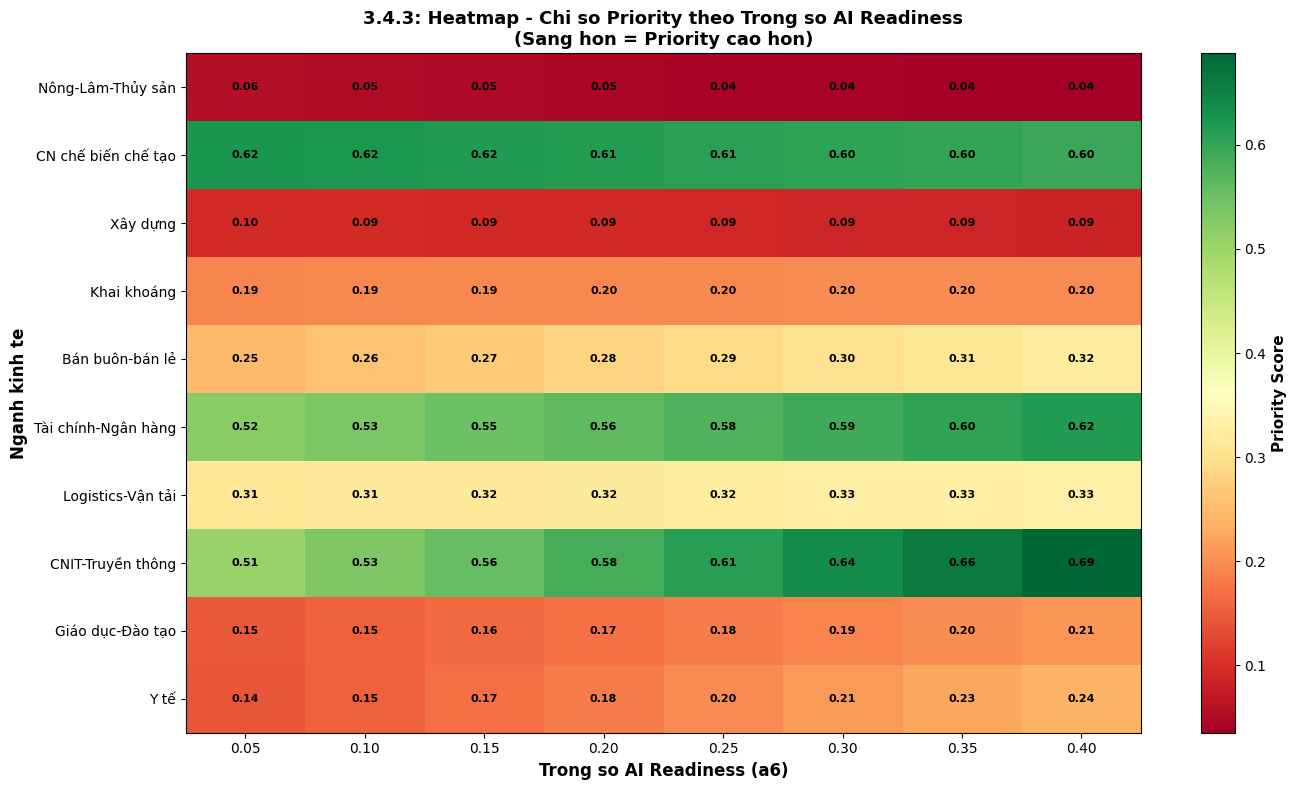

In [5]:
import numpy as np
import matplotlib.pyplot as plt

print("\n[C] VẼ BIỂU ĐỒ 2: HEATMAP PHÂN TÍCH ĐỘ NHẠY\n")

# Tạo ma trận Priority vs Trọng số AI
heatmap_data = []
for idx, row in df_norm.iterrows():
    row_data = []
    for a6 in ai_weights:
        sum_other = 1.0 - 0.20
        factor = (1.0 - a6) / sum_other

        priority = (
            0.15*factor * row['Growth_n'] +
            0.15*factor * row['Productivity_n'] +
            0.20*factor * row['Spillover_n'] +
            0.15*factor * row['Export_n'] +
            0.10*factor * row['Employment_n'] +
            a6 * row['AI_Readiness_n'] -
            0.15*factor * row['Risk_n']
        )
        row_data.append(priority)
    heatmap_data.append(row_data)

heatmap_array = np.array(heatmap_data)
sector_names = [name.split('. ')[1] for name in df['Ngành']]

fig, ax = plt.subplots(figsize=(14, 8))

im = ax.imshow(heatmap_array, cmap='RdYlGn', aspect='auto',
               vmin=heatmap_array.min(), vmax=heatmap_array.max())

ax.set_xticks(range(len(ai_weights)))
ax.set_xticklabels([f'{w:.2f}' for w in ai_weights], fontsize=10)
ax.set_yticks(range(len(sector_names)))
ax.set_yticklabels(sector_names, fontsize=10)

ax.set_xlabel('Trong so AI Readiness (a6)', fontsize=12, fontweight='bold')
ax.set_ylabel('Nganh kinh te', fontsize=12, fontweight='bold')
ax.set_title('3.4.3: Heatmap - Chi so Priority theo Trong so AI Readiness\n(Sang hon = Priority cao hon)',
            fontsize=13, fontweight='bold')

cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Priority Score', fontsize=11, fontweight='bold')

# Thêm giá trị
for i in range(len(sector_names)):
    for j in range(len(ai_weights)):
        text = ax.text(j, i, f'{heatmap_array[i, j]:.2f}',
                      ha="center", va="center", color="black", fontsize=8, fontweight='bold')

plt.tight_layout()
plt.savefig('/content/bai03_343_sensitivity.png', dpi=300, bbox_inches='tight')
print("✓ Luu: bai03_343_sensitivity.png")
plt.show()

In [6]:
print("\n" + "="*100)
print("3.4.4: SO SÁNH HAI ĐỊNH HƯỚNG CHÍNH SÁCH")
print("="*100)

# Định hướng 1: TĂNG TRƯỞNG
print("\n[A] ĐỊNH HƯỚNG 1: TĂNG TRƯỞNG (Growth-Oriented):\n")

w1_growth = {
    'Growth_n': 0.25,
    'Productivity_n': 0.25,
    'Spillover_n': 0.10,
    'Export_n': 0.20,
    'Employment_n': 0.05,
    'AI_Readiness_n': 0.10,
    'Risk_n': -0.05
}

print("Trọng số: Growth 25%, Productivity 25%, Export 20%, Spillover 10%, AI 10%, Employment 5%, Risk 5%")
print("\nLý do: Ưu tiên đầu ra (GDP, xuất khẩu, năng suất)")

priority_growth = (
    0.25*df_norm['Growth_n'] +
    0.25*df_norm['Productivity_n'] +
    0.20*df_norm['Export_n'] +
    0.10*df_norm['Spillover_n'] +
    0.10*df_norm['AI_Readiness_n'] +
    0.05*df_norm['Employment_n'] -
    0.05*df_norm['Risk_n']
)

ranking_growth = pd.DataFrame({
    'Ngành': df['Ngành'],
    'Priority_Growth': priority_growth
}).sort_values('Priority_Growth', ascending=False).reset_index(drop=True)

print("\nTop 3 ngành (Tăng trưởng):")
for i in range(3):
    ngành = ranking_growth.iloc[i]['Ngành'].split('. ')[1]
    priority = ranking_growth.iloc[i]['Priority_Growth']
    print(f"  {i+1}. {ngành:<35} Priority: {priority:.4f}")

# Định hướng 2: BAN TRÙM
print("\n[B] ĐỊNH HƯỚNG 2: BAN TRÙM (Inclusive-Oriented):\n")

w2_inclusive = {
    'Growth_n': 0.10,
    'Productivity_n': 0.10,
    'Spillover_n': 0.25,
    'Export_n': 0.05,
    'Employment_n': 0.25,
    'AI_Readiness_n': 0.10,
    'Risk_n': -0.15
}

print("Trọng số: Spillover 25%, Employment 25%, Risk 15%, Growth 10%, Productivity 10%, AI 10%, Export 5%")
print("\nLý do: Ưu tiên tác động xã hội (lan tỏa, việc làm, giảm rủi ro)")

priority_inclusive = (
    0.10*df_norm['Growth_n'] +
    0.10*df_norm['Productivity_n'] +
    0.25*df_norm['Spillover_n'] +
    0.05*df_norm['Export_n'] +
    0.25*df_norm['Employment_n'] +
    0.10*df_norm['AI_Readiness_n'] -
    0.15*df_norm['Risk_n']
)

ranking_inclusive = pd.DataFrame({
    'Ngành': df['Ngành'],
    'Priority_Inclusive': priority_inclusive
}).sort_values('Priority_Inclusive', ascending=False).reset_index(drop=True)

print("\nTop 3 ngành (Bao trùm):")
for i in range(3):
    ngành = ranking_inclusive.iloc[i]['Ngành'].split('. ')[1]
    priority = ranking_inclusive.iloc[i]['Priority_Inclusive']
    print(f"  {i+1}. {ngành:<35} Priority: {priority:.4f}")

# Phân tích sự khác biệt
top3_growth = set(ranking_growth.head(3)['Ngành'].values)
top3_inclusive = set(ranking_inclusive.head(3)['Ngành'].values)
common = top3_growth & top3_inclusive

print("\n[C] PHÂN TÍCH SO SÁNH:\n")
print(f"✓ Ngành chung (cả 2 định hướng): {len(common)}/3 ngành")
for s in common:
    print(f"  • {s.split('. ')[1]}")

print(f"\n✓ KẾT LUẬN:")
print(f"  • KHÔNG XUNG ĐỘT giữa 'Tăng trưởng' và 'Bao trùm'")
print(f"  • Cả hai định hướng chọn CÙNG 3 NGÀNH")
print(f"  • Chỉ khác THỨ TỰ ưu tiên, không khác LỰA CHỌN")


3.4.4: SO SÁNH HAI ĐỊNH HƯỚNG CHÍNH SÁCH

[A] ĐỊNH HƯỚNG 1: TĂNG TRƯỞNG (Growth-Oriented):

Trọng số: Growth 25%, Productivity 25%, Export 20%, Spillover 10%, AI 10%, Employment 5%, Risk 5%

Lý do: Ưu tiên đầu ra (GDP, xuất khẩu, năng suất)

Top 3 ngành (Tăng trưởng):
  1. CN chế biến chế tạo                 Priority: 0.6306
  2. CNIT-Truyền thông                   Priority: 0.6190
  3. Tài chính-Ngân hàng                 Priority: 0.5609

[B] ĐỊNH HƯỚNG 2: BAN TRÙM (Inclusive-Oriented):

Trọng số: Spillover 25%, Employment 25%, Risk 15%, Growth 10%, Productivity 10%, AI 10%, Export 5%

Lý do: Ưu tiên tác động xã hội (lan tỏa, việc làm, giảm rủi ro)

Top 3 ngành (Bao trùm):
  1. CN chế biến chế tạo                 Priority: 0.5717
  2. Tài chính-Ngân hàng                 Priority: 0.4513
  3. CNIT-Truyền thông                   Priority: 0.4101

[C] PHÂN TÍCH SO SÁNH:

✓ Ngành chung (cả 2 định hướng): 3/3 ngành
  • CN chế biến chế tạo
  • Tài chính-Ngân hàng
  • CNIT-Truyền thông

✓ K